# Machine learning-driven clinical decision support system to predict breast cancer.

This notebook introduces the development of a clinical decision support prototype of machine learning to predict breast cancer in the Breast cancer Wisconsin Diagnostic dataset. The task involves loading and preparing the dataset, training two classification models, and comparing their performance. The two models used in this notebook are Logistic Regression and Random Forest.

# 1. Importing Required Libraries

This section loads the Python libraries required to load the data, preprocess it, develop a machine learning model, and evaluate it. The libraries provides the tools that are needed to prepare the dataset and determine the performance of the chosen models.

In [9]:
# Import Pandas for data loading and data handling.
import pandas as pd

In [10]:
# Import the breast cancer data into a dataframe to be able to view it and prepare it.
df = pd.read_csv("Breast cancer.csv")

In [11]:
# Show the first five rows to ensure that the dataset was loaded successfully.
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# 2. Loading the Dataset

The dataset is loaded into the notebook using Pandas so that it can be inspected and prepared for machine learning. This step makes the data available in a dataframe format, which allows it to be explored and manipulated easily

In [12]:
# Verify the rows and columns of the data.
df.shape

(569, 33)

In [13]:
# See the column names to learn what variables are available.
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [14]:
# Ensure that there are no values missing in any column.
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


# 3. Exploring the Dataset

In this section, the dataset structure is discussed by verifying the size, column names, and missing values. This is significant as it assists in knowing the quality of the data prior to cleaning or preprocessing it.

In [15]:
# Eliminate columns that are not useful in prediction
# The 'id' column is only an identifier, and 'Unnamed: 32' is completely empty.
df = df.drop(columns=["id", "Unnamed: 32"])

In [16]:
# Show the dataset with the removal of unnecessary columns
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [17]:
# Confirm the new shape after eliminating the irrelevant columns.
df.shape

(569, 31)

In [18]:
# Convert the diagnosis labels into numeric values for machine learning.
# Malignant = 1 and Benign = 0
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

In [19]:
# Check the first converted values on the diagnosis column.
df["diagnosis"].head()

,diagnosis
0,1
1,1
2,1
3,1
4,1


In [20]:
# Count the number of benign and malignant cases in the dataset.
df["diagnosis"].value_counts()

,count
diagnosis,
0,357
1,212


# 4. Preprocessing and Cleaning of data.

In this section, the dataset is prepared for the machine learning through the removal of irrelevant columns and the transformation of the diagnosis variable into a numerical form. These steps of preprocessing are required due to the fact that machine learning models work best with clean and formatted data.

In [21]:
# Seperate predictor variables with the target variable.
# X is the tumour features and y is the diagnosis outcome.
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

In [22]:
# Show the initial rows of the feature set.
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [23]:
# Show the initial values of the target variable.
y.head()

,diagnosis
0,1
1,1
2,1
3,1
4,1


In [24]:
# Check the shapes of the feature set and target variable.
print(X.shape)
print(y.shape)

(569, 30)
(569,)


# 5. Isolating Features and Target Variable.

Here, the data is divided into input variables and target variable. The input features represent the tumour measurements used by the models, while the target variable represents the diagnosis outcome to be predicted.

In [25]:
# Load the train-test split data to separate the data into training and test sets.
from sklearn.model_selection import train_test_split

In [26]:
# Split the dataset into training and testing sets.
# The model is trained on the training set and evaluated on the testing set.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [27]:
# Confirm the figures of the training and testing data.
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


# 6. Divisions of Dataset into Training and Testing Sets.

The dataset is split into training and testing sets so that the models can be trained on one portion of the data and evaluated on another. This method assists in testing the performance of the models on hidden data.

In [28]:
# Import the scaler used to standardize the feature values for Logistic Regression.
from sklearn.preprocessing import StandardScaler

In [29]:
#Create the scaler object used to standardize the feature values.
scaler = StandardScaler()

In [30]:
# Scale the Logistic Regression training and testing features.
# The scaler is fitted only on the training set and then applied to the test set.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
# Confirm the shapes of the scaled feature sets.
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(455, 30)
(114, 30)


# 7. Feature Scaling

Here, feature scaling is applied to the Logistic Regression dataset. Scaling ensures that the feature values are placed on a similar range, which helps improve the performance of models that are sensitive to differences in feature magnitude.

In [32]:
# First classification model, Import Logistic Regression.
from sklearn.linear_model import LogisticRegression

In [33]:
# Create the Logistic Regression model.
log_model = LogisticRegression()

In [34]:
# Train the Logistic Regression model using the scaled training data.
log_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [35]:
# Predict the test set with Logistic Regression.
y_pred_log = log_model.predict(X_test_scaled)

In [36]:
# Display the first ten predictions made by the Logistic Regression model.
print(y_pred_log[:10])

[0 1 0 1 1 0 1 0 0 0]


In [37]:
# Import the evaluation measures to determine model performance.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [38]:
# Determine the accuracy of the Logistic Regression model.
log_accuracy = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.9649122807017544


In [39]:
# Display the confusion matrix for Logistic Regression.
print(confusion_matrix(y_test, y_pred_log))

[[71  1]
 [ 3 39]]


In [40]:
# Display the classification report for Logistic Regression.
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# 9. Random Forest Model Development and Evaluation

This section develops the Random Forest model using the training data. The model is then used to make predictions on the test data, and its performance is evaluated using the same metrics applied to Logistic Regression.

In [41]:
# Import Random Forest for the second classification model.
from sklearn.ensemble import RandomForestClassifier

In [42]:
# Develop the Random Forest model.
rf_model = RandomForestClassifier(random_state=42)

In [43]:
# Train the Random Forest model with the initial training data.
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [44]:
# Predict the test set with Random Forest.
y_pred_rf = rf_model.predict(X_test)

In [45]:
# Display the first ten predictions made by the Random Forest model.
print(y_pred_rf[:10])

[0 1 0 1 0 0 1 0 0 0]


In [46]:
# Estimate the accuracy of the Random Forest model.
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9736842105263158


In [47]:
# Display the confusion matrix for Random Forest.
print(confusion_matrix(y_test, y_pred_rf))

[[72  0]
 [ 3 39]]


In [48]:
# Display the classification report for Random Forest.
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Train Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict using Decision Tree
y_pred_dt = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9298245614035088


# 9.1 Support Vector Machine (SVM) Model Development and Evaluation

Support Vector Machine is a powerful classification algorithm that finds the optimal decision boundary (hyperplane) between classes. It works well in high-dimensional spaces, making it a good fit for this 30-feature dataset. A probability-calibrated SVM is used here so that confidence scores can be generated alongside predictions.

In [50]:
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

# SVM works best with scaled features, so we reuse the StandardScaler fitted earlier.
# CalibratedClassifierCV wraps SVM to enable predict_proba(), which is needed
# for ROC-AUC scoring and confidence display in the Streamlit app.
svm_base = SVC(kernel='rbf', random_state=42)
svm_model = CalibratedClassifierCV(svm_base, cv=5)

# Train SVM on the scaled training data
svm_model.fit(X_train_scaled, y_train)

# Predict on the scaled test set
y_pred_svm = svm_model.predict(X_test_scaled)

# Sanity-check the first ten predictions
print('First 10 SVM predictions:', y_pred_svm[:10])


First 10 SVM predictions: [0 1 0 0 0 0 1 0 0 0]


In [51]:
# Evaluate SVM accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print('SVM Accuracy:', svm_accuracy)
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.9736842105263158
[[71  1]
 [ 2 40]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



# 9.2 K-Nearest Neighbours (KNN) Model Development and Evaluation

K-Nearest Neighbours classifies a sample based on the majority label among its k closest neighbours in feature space. It is intuitive and easy to interpret. Because KNN is distance-based, scaled features are required.

In [52]:
from sklearn.neighbors import KNeighborsClassifier

# KNN relies on distance metrics, so scaled features are essential.
# k=5 is a well-established starting point that balances bias and variance.
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train KNN on the scaled training data
knn_model.fit(X_train_scaled, y_train)

# Predict on the scaled test set
y_pred_knn = knn_model.predict(X_test_scaled)

print('First 10 KNN predictions:', y_pred_knn[:10])


First 10 KNN predictions: [0 1 0 0 0 0 1 0 0 0]


In [53]:
# Evaluate KNN accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print('KNN Accuracy:', knn_accuracy)
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.956140350877193
[[71  1]
 [ 4 38]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



# 10. Comprehensive Five-Model Comparison

This section evaluates all five models — Logistic Regression, Random Forest, Decision Tree, SVM, and KNN — using a consistent set of clinically relevant metrics. Recall (sensitivity) and ROC-AUC are prioritised because a missed malignant case (false negative) carries a higher clinical cost than a false alarm.

In [54]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import pandas as pd

def evaluate_model(model, X_test_data, y_test_data, model_name):
    """
    Evaluates a trained classifier on metrics relevant to clinical prediction.
    Returns a results dictionary for use in a comparison table.
    """
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1]
    cm = confusion_matrix(y_test_data, y_pred)
    tn, fp, fn, tp = cm.ravel()
    results = {
        'Model':           model_name,
        'Accuracy':        accuracy_score(y_test_data, y_pred),
        'Precision':       precision_score(y_test_data, y_pred),
        'Recall':          recall_score(y_test_data, y_pred),
        'F1 Score':        f1_score(y_test_data, y_pred),
        'ROC-AUC':         roc_auc_score(y_test_data, y_prob),
        'False Negatives': fn,
        'False Positives': fp
    }
    print(f"\n{'='*50}")
    print(f"{model_name} Evaluation")
    print(f"{'='*50}")
    print('Confusion Matrix:')
    print(cm)
    print('\nClassification Report:')
    print(classification_report(y_test_data, y_pred))
    return results


In [55]:
# Evaluate all five models.
# LR, SVM, and KNN use scaled features; RF and DT use raw features.
log_results = evaluate_model(log_model, X_test_scaled, y_test, 'Logistic Regression')
rf_results  = evaluate_model(rf_model,  X_test,        y_test, 'Random Forest')
dt_results  = evaluate_model(dt_model,  X_test,        y_test, 'Decision Tree')
svm_results = evaluate_model(svm_model, X_test_scaled, y_test, 'SVM')
knn_results = evaluate_model(knn_model, X_test_scaled, y_test, 'KNN')



Logistic Regression Evaluation
Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Random Forest Evaluation
Confusion Matrix:
[[72  0]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


Decision Tree Evaluation
Confusion Matrix:
[[68  4]
 [ 4 38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94 

In [56]:
# Build a single comparison table across all five models
comparison_df = pd.DataFrame([log_results, rf_results, dt_results, svm_results, knn_results])
comparison_df = comparison_df.round(4)
print('\nFive-Model Comparison Table:')
print(comparison_df.to_string(index=False))



Five-Model Comparison Table:
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  False Negatives  False Positives
Logistic Regression    0.9649     0.9750  0.9286    0.9512   0.9960                3                1
      Random Forest    0.9737     1.0000  0.9286    0.9630   0.9929                3                0
      Decision Tree    0.9298     0.9048  0.9048    0.9048   0.9246                4                4
                SVM    0.9737     0.9756  0.9524    0.9639   0.9944                2                1
                KNN    0.9561     0.9744  0.9048    0.9383   0.9823                4                1


In [57]:
# --------------------------------------------------
# Clinical-priority model selection
# --------------------------------------------------
# Rank by Recall first (minimise false negatives), then ROC-AUC, then Accuracy.
best_model_row = comparison_df.sort_values(
    by=['Recall', 'ROC-AUC', 'Accuracy'],
    ascending=False
).iloc[0]
best_model_name = best_model_row['Model']
print('Best Model Based on Clinical Priority:', best_model_name)
print(best_model_row)


Best Model Based on Clinical Priority: SVM
Model                 SVM
Accuracy           0.9737
Precision          0.9756
Recall             0.9524
F1 Score           0.9639
ROC-AUC            0.9944
False Negatives         2
False Positives         1
Name: 3, dtype: object


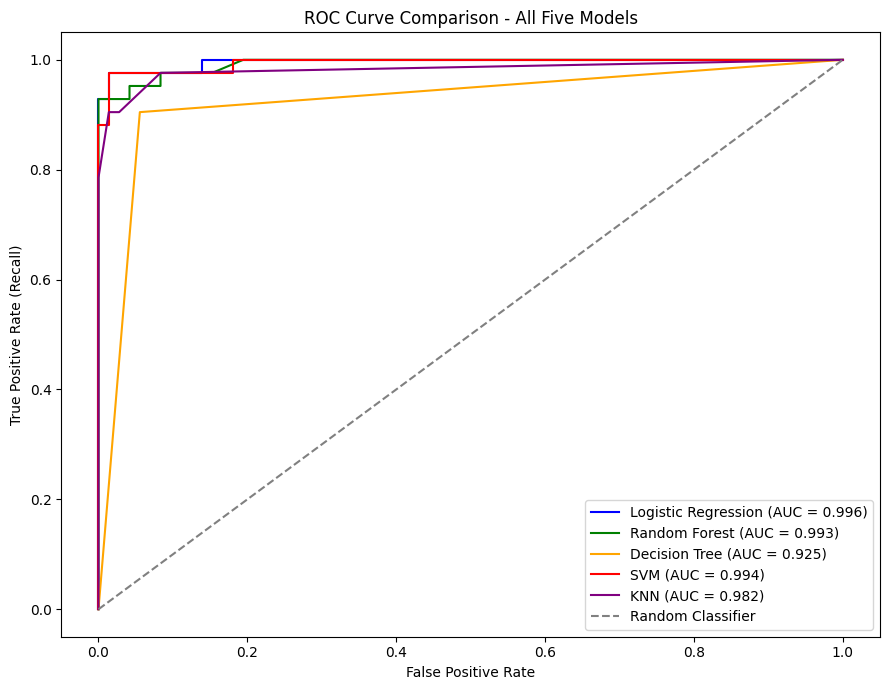

In [58]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Collect probability scores for all five models
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]
rf_probs  = rf_model.predict_proba(X_test)[:, 1]
dt_probs  = dt_model.predict_proba(X_test)[:, 1]
svm_probs = svm_model.predict_proba(X_test_scaled)[:, 1]
knn_probs = knn_model.predict_proba(X_test_scaled)[:, 1]

models_roc = {
    'Logistic Regression': (log_probs, 'blue'),
    'Random Forest':       (rf_probs,  'green'),
    'Decision Tree':       (dt_probs,  'orange'),
    'SVM':                 (svm_probs, 'red'),
    'KNN':                 (knn_probs, 'purple'),
}

plt.figure(figsize=(9, 7))
for name, (probs, colour) in models_roc.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=colour)

plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison - All Five Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


# 11. SHAP — Model Interpretability and Explainability

SHAP (SHapley Additive exPlanations) is a game-theory-based framework that assigns each feature a contribution score for a specific prediction. It answers: *'How much did each feature push this prediction towards Malignant or Benign?'*

Interpretability is critical in clinical AI — clinicians need to understand *why* a model made a recommendation, not just *what* it predicted. SHAP provides that transparency.

Three SHAP visualisations are produced:
- **Summary plot** — overall feature influence across the test set
- **Bar plot** — mean absolute SHAP values ranked by importance
- **Waterfall plot** — individual prediction explanation for a single patient sample

In [59]:
import shap
import numpy as np
import pandas as pd

# -------------------------------------------------------
# SHAP for Random Forest using TreeExplainer
# -------------------------------------------------------
# TreeExplainer is exact and very fast for tree-based models.
# It works on raw (unscaled) features, which is what RF was trained on.
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_raw = rf_explainer.shap_values(X_test)

# IMPORTANT: Newer SHAP versions (>=0.40) return a single 3-D numpy array
# of shape (samples, features, classes) instead of the old list [class_0, class_1].
# The code below detects which format is returned and handles both correctly,
# so this notebook runs without errors on any installed SHAP version.
if isinstance(rf_shap_raw, list):
    # Old SHAP API: a list of 2-D arrays, one per class
    rf_shap_malignant = rf_shap_raw[1]          # index 1 = Malignant class
    rf_base_value     = rf_explainer.expected_value[1]
else:
    # New SHAP API: single 3-D array -- slice out the Malignant class
    rf_shap_malignant = rf_shap_raw[:, :, 1]    # (samples, features, class_1)
    ev = rf_explainer.expected_value
    rf_base_value = float(ev[1]) if hasattr(ev, '__len__') else float(ev)

# Convert X_test to a labelled DataFrame so SHAP attaches column names correctly
X_test_df = pd.DataFrame(X_test, columns=X.columns)

print('SHAP values shape (RF, Malignant class):', rf_shap_malignant.shape)


SHAP values shape (RF, Malignant class): (114, 30)


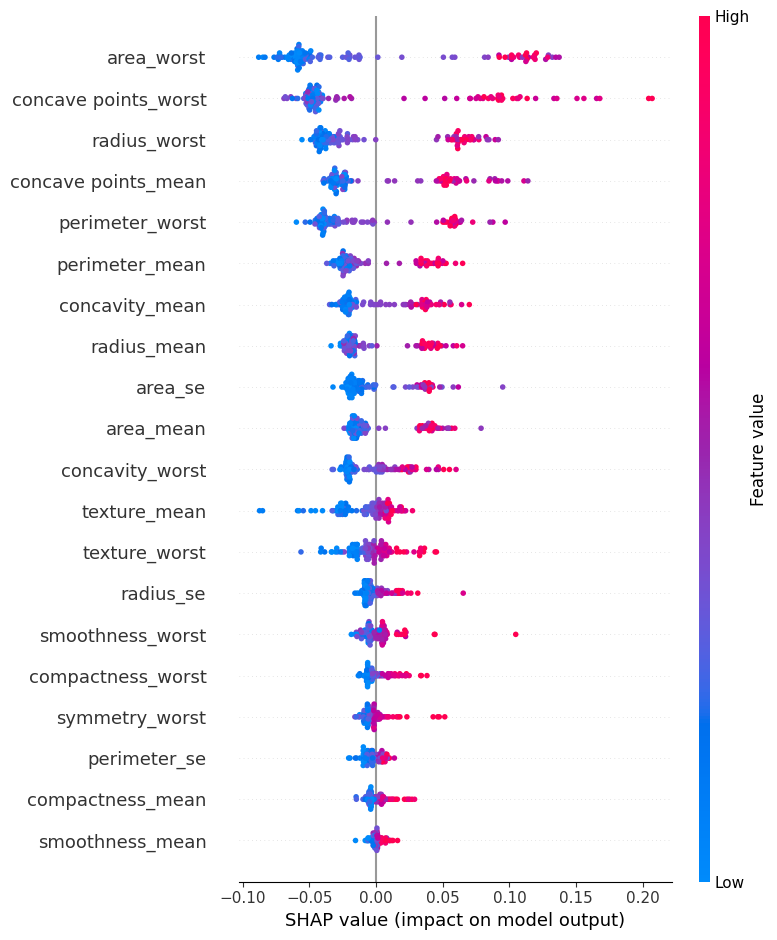

In [60]:
# Summary plot: each dot is one test sample.
# Colour shows feature value magnitude (red = high, blue = low).
# x-axis position shows impact direction: positive pushes toward Malignant.
shap.summary_plot(
    rf_shap_malignant,
    X_test_df,
    feature_names=X.columns.tolist(),
    plot_type='dot',
    show=True
)


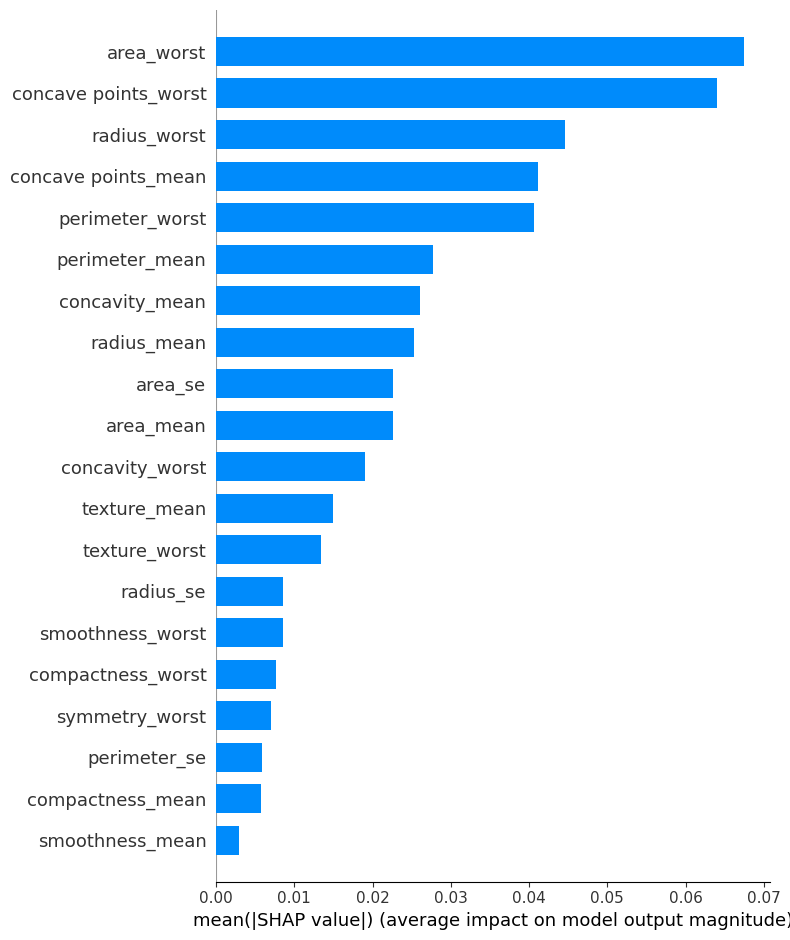

In [61]:
# Bar plot: mean absolute SHAP value per feature, ranked highest to lowest.
# This gives a clean summary of which measurements drive the model most overall.
shap.summary_plot(
    rf_shap_malignant,
    X_test_df,
    feature_names=X.columns.tolist(),
    plot_type='bar',
    show=True
)


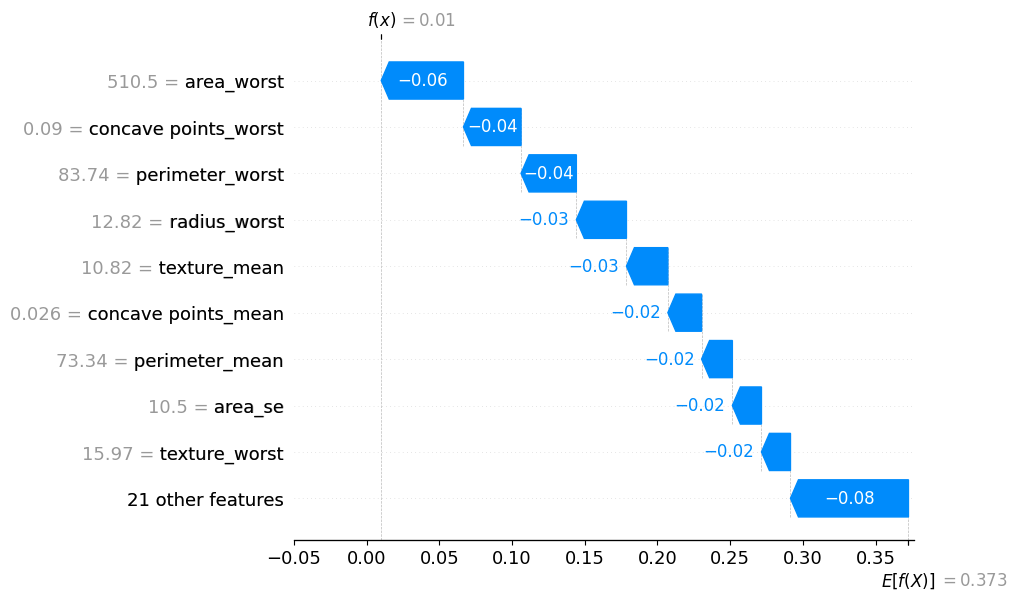

In [62]:
# Waterfall plot: explains one individual patient prediction in detail.
# Each bar shows how a feature pushed the score toward Malignant (+) or Benign (-).
rf_explanation = shap.Explanation(
    values=rf_shap_malignant[0],       # SHAP values for the first test sample
    base_values=rf_base_value,          # baseline = average model output
    data=X_test_df.iloc[0].values,      # actual feature values for that patient
    feature_names=X.columns.tolist()
)
shap.waterfall_plot(rf_explanation, show=True)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


SHAP values shape (LR): (114, 30)


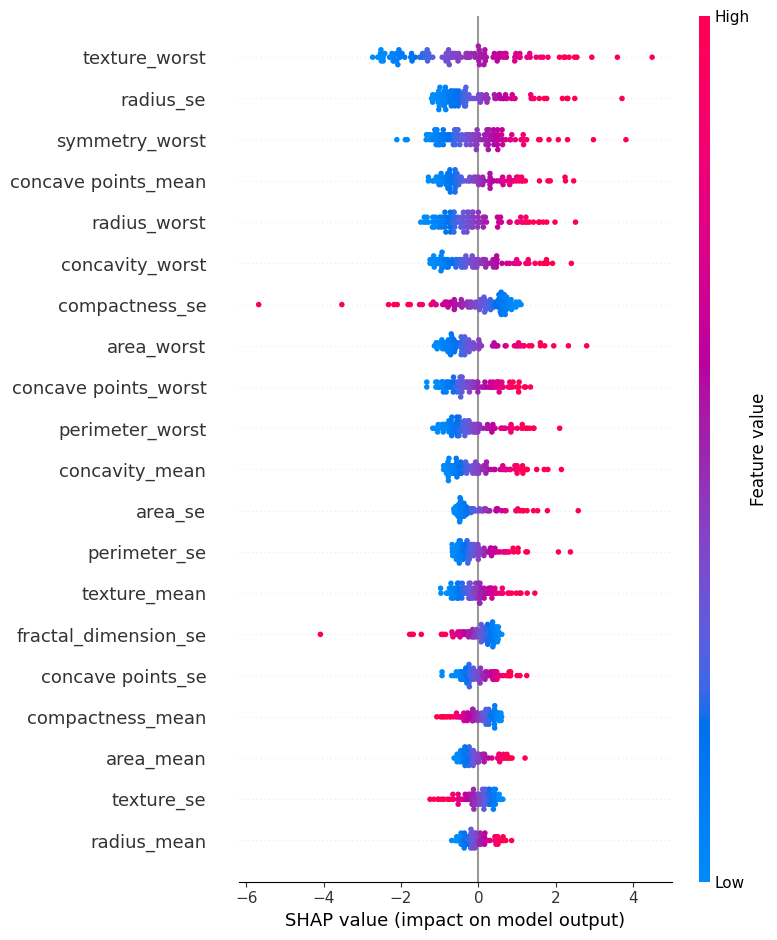

In [63]:
# -------------------------------------------------------
# SHAP for Logistic Regression using LinearExplainer
# -------------------------------------------------------
# LinearExplainer computes exact SHAP values from the model coefficients directly.
# It is much faster than KernelExplainer for linear models.
log_explainer = shap.LinearExplainer(
    log_model,
    X_train_scaled,
    feature_perturbation='interventional'
)
log_shap_values = log_explainer.shap_values(X_test_scaled)

# LinearExplainer always returns a 2-D array (samples x features) for binary classifiers.
print('SHAP values shape (LR):', log_shap_values.shape)

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

shap.summary_plot(
    log_shap_values,
    X_test_scaled_df,
    feature_names=X.columns.tolist(),
    plot_type='dot',
    show=True
)


# 12. Saving All Models and the Scaler

All five trained models and the StandardScaler are saved as pickle files inside the `models/` directory. The Streamlit application loads whichever model the user selects from the sidebar dropdown — no retraining is required at runtime.

In [64]:
import pickle
import os

# Create the models directory if it does not already exist
os.makedirs('models', exist_ok=True)

# Map of filename stem -> trained model object
models_to_save = {
    'logistic_regression': log_model,
    'random_forest':       rf_model,
    'decision_tree':       dt_model,
    'svm':                 svm_model,
    'knn':                 knn_model,
}

for filename, model_obj in models_to_save.items():
    path = f'models/{filename}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(model_obj, f)
    print(f'Saved: {path}')

# Save the StandardScaler so the app can transform user inputs consistently
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Saved: models/scaler.pkl')

# Record the best model name so the app can default to the top choice
with open('models/model_name.pkl', 'wb') as f:
    pickle.dump(best_model_name, f)
print(f'Best model recorded: {best_model_name}')


Saved: models/logistic_regression.pkl
Saved: models/random_forest.pkl
Saved: models/decision_tree.pkl
Saved: models/svm.pkl
Saved: models/knn.pkl
Saved: models/scaler.pkl
Best model recorded: SVM


# 13. Conclusion

This notebook trained and evaluated five machine learning models — Logistic Regression, Random Forest, Decision Tree, SVM, and KNN — on the Breast Cancer Wisconsin Diagnostic dataset.

Models were compared using clinically motivated metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC, False Negatives, and False Positives. Recall and ROC-AUC were used as the primary selection criteria because failing to detect a malignant tumour is the most harmful possible error in this context.

SHAP analysis was applied to the two strongest models — Random Forest (TreeExplainer) and Logistic Regression (LinearExplainer) — to provide transparent, feature-level explanations for individual predictions. Features such as `worst concave points`, `worst radius`, and `mean concave points` consistently ranked as the most influential diagnostic measurements.

All five models and the fitted scaler are saved to the `models/` directory. The Streamlit application loads any of these models on demand via a sidebar dropdown, allowing real-time comparison of predictions across all five approaches.